In [1]:
pip install numpy Pillow Matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Cell 1: Imports and Class Definition

from PIL import Image
import numpy as np
import time
import os
import matplotlib.pyplot as plt

class KMeansImpl:
    def __init__(self, max_iterations=20, num_runs=1):
        """
        Initializes KMeansImpl with parameters for the clustering algorithm.
        :param max_iterations: Maximum number of iterations for K-means convergence.
        :param num_runs: Number of random initializations to try for each (image, k) pair.
        """
        self.max_iterations = max_iterations
        self.num_runs = num_runs

    def load_image(self, image_name): # Removed default to make it explicit in main script
        """
        Loads an image and returns its numpy array.
        Assumes image_name is either a direct path or relative to 'data/' folder.
        """
        full_path = os.path.join("data", image_name)
        if not os.path.exists(full_path):
             # Try direct path if not found in data folder
             full_path = image_name
             if not os.path.exists(full_path):
                 print(f"Error: Image not found at {full_path}. Please check the path.")
                 return None
        return np.array(Image.open(full_path).convert('RGB')) # Ensure RGB for consistency

    def _initialize_centroids(self, pixels_flat, k):
        """
        Randomly initializes k centroids from the pixel data.
        :param pixels_flat: Flattened image pixels (N, 3).
        :param k: Number of clusters.
        :return: Initial centroids (k, 3).
        """
        indices = np.random.choice(pixels_flat.shape[0], k, replace=False)
        return pixels_flat[indices]

    def _assign_clusters(self, pixels_flat, centroids, norm_distance):
        """
        Assigns each pixel to the closest centroid based on the specified distance metric.
        :param pixels_flat: Flattened image pixels (N, 3).
        :param centroids: Current cluster centroids (k, 3).
        :param norm_distance: 1 for Manhattan (L1), 2 for Euclidean (L2).
        :return: An array of cluster assignments (labels) for each pixel (N,).
        """
        if norm_distance == 1: # Manhattan (L1) distance
            distances = np.sum(np.abs(pixels_flat[:, np.newaxis, :] - centroids[np.newaxis, :, :]), axis=2)
        elif norm_distance == 2: # Squared Euclidean (L2) distance
            distances = np.sum((pixels_flat[:, np.newaxis, :] - centroids[np.newaxis, :, :])**2, axis=2)
        else:
            raise ValueError("norm_distance must be 1 (Manhattan) or 2 (Euclidean).")

        return np.argmin(distances, axis=1)

    def _update_centroids(self, pixels_flat, assignments, k_actual):
        """
        Recalculates centroids as the mean of assigned pixels.
        Handles empty clusters by re-initializing them with a random data point.
        :param pixels_flat: Flattened image pixels (N, 3).
        :param assignments: Current cluster assignments (N,).
        :param k_actual: The current number of active clusters.
        :return: Updated centroids (k_actual, 3).
        """
        new_centroids = np.zeros((k_actual, pixels_flat.shape[1]))

        for j in range(k_actual):
            points_in_cluster = pixels_flat[assignments == j]
            if len(points_in_cluster) > 0:
                new_centroids[j] = np.mean(points_in_cluster, axis=0)
            else:
                # Handle empty cluster by re-initializing its centroid randomly from existing pixels
                print(f"Warning: Cluster {j} is empty. Re-initializing centroid randomly.")
                new_centroids[j] = pixels_flat[np.random.choice(pixels_flat.shape[0])]
        return new_centroids

    def _calculate_distortion(self, pixels_flat, assignments, centroids, norm_distance):
        """
        Calculates the distortion for a given clustering.
        """
        distortion = 0.0
        for i in range(pixels_flat.shape[0]):
            assigned_centroid = centroids[assignments[i]]
            if norm_distance == 1: # Manhattan distance
                distortion += np.sum(np.abs(pixels_flat[i] - assigned_centroid))
            elif norm_distance == 2: # Squared Euclidean distance
                distortion += np.sum((pixels_flat[i] - assigned_centroid)**2)
        return distortion

    def compress(self, pixels, num_clusters, norm_distance=2):
        """
        Compress the image using K-Means clustering.

        Parameters:
            pixels: 3D image for each channel (height, width, 3), values range from 0 to 255.
            num_clusters: Number of clusters (k) to use for compression.
            norm_distance: Type of distance metric to use for clustering.
                            Can be 1 for Manhattan distance or 2 for Euclidean distance.
                            Default is 2 (Euclidean).

        Returns:
            Dictionary containing:
                "class": The cluster number assigned to each pixel (flattened).
                "centroid": Locations of the cluster centroids (k, 3) in [0, 1] scale.
                "img": Compressed image (PIL Image object).
                "number_of_iterations": total iterations taken by algorithm.
                "time_taken": time taken by the compression algorithm.
                "distortion": Final distortion value of the best run.
        """
        original_shape = pixels.shape
        pixels_flat = pixels.reshape(-1, 3) / 255.0 # Flatten and normalize to [0, 1]

        best_assignments = None
        best_centroids = None
        best_num_iterations = 0
        best_time_taken = 0.0
        min_distortion = float('inf')

        print(f"  Attempting {self.num_runs} runs for k={num_clusters}, norm={norm_distance}...")
        for run_idx in range(self.num_runs):
            start_time = time.time()
            
            centroids = self._initialize_centroids(pixels_flat, num_clusters)
            prev_assignments = None
            current_iterations = 0

            for i in range(self.max_iterations):
                current_iterations = i + 1
                assignments = self._assign_clusters(pixels_flat, centroids, norm_distance)

                if prev_assignments is not None and np.array_equal(assignments, prev_assignments):
                    break # Converged
                
                centroids = self._update_centroids(pixels_flat, assignments, num_clusters)
                prev_assignments = assignments
            
            time_taken = time.time() - start_time
            current_distortion = self._calculate_distortion(pixels_flat, assignments, centroids, norm_distance)

            if current_distortion < min_distortion:
                min_distortion = current_distortion
                best_assignments = assignments
                best_centroids = centroids
                best_num_iterations = current_iterations
                best_time_taken = time_taken
        
        reconstructed_pixels_normalized = best_centroids[best_assignments]
        reconstructed_pixels_uint8 = (reconstructed_pixels_normalized * 255).astype(np.uint8)
        reconstructed_img = Image.fromarray(reconstructed_pixels_uint8.reshape(original_shape))

        return {
            "class": best_assignments,
            "centroid": (best_centroids * 255).astype(np.uint8),
            "img": reconstructed_img,
            "number_of_iterations": best_num_iterations,
            "time_taken": best_time_taken,
            "distortion": min_distortion,
            "additional_args": {}
        }

In [7]:
# Cell 2: Setup and Configuration

# Initialize the K-means processor
# You can adjust max_iterations and num_runs here.
# num_runs=2 
kmeans_processor = KMeansImpl(max_iterations=20, num_runs=1) 

# Define image paths
image_paths = {
    "georgia-aquarium": "georgia-aquarium.jpg",
    "football": "football.jpg",
    "flower": "flower.jpg" # Your chosen third image
}

# Define K values to test
k_values = [5, 10, 20, 30, 40]

# Define distance norms to test
norm_distances = {
    "l2": 2, # Squared Euclidean distance
    "l1": 1  # Manhattan distance
}

# Dictionary to store all results for easy access and reporting
all_results = {
    "l2": {},
    "l1": {}
}

# Create base output directory if it doesn't exist
output_base_dir = "kmeans_compression_results"
os.makedirs(output_base_dir, exist_ok=True)

print("Setup complete. Ready to run K-means compression.")

Setup complete. Ready to run K-means compression.


In [3]:
# Cell 3: Run K-means Compression and Save Results

for dist_type, norm_val in norm_distances.items():
    print(f"\n--- Running K-means with {dist_type.upper()} norm ---")
    all_results[dist_type] = {} # Initialize results for this distance type

    # Create output directory for current distance type
    output_dist_dir = os.path.join(output_base_dir, dist_type)
    os.makedirs(output_dist_dir, exist_ok=True)

    for image_name, path in image_paths.items():
        print(f"\nProcessing {image_name} for {dist_type.upper()} norm...")
        pixels = kmeans_processor.load_image(path)
        if pixels is None:
            continue # Skip if image loading failed

        # Initialize results storage for current image and distance type
        all_results[dist_type][image_name] = {
            'times': [],
            'iterations': [],
            'distortions': [],
            'reconstructed_image_paths': {}
        }

        for k in k_values:
            print(f"  K={k}")
            result = kmeans_processor.compress(pixels, k, norm_distance=norm_val)
            
            # Store results
            all_results[dist_type][image_name]['times'].append(result['time_taken'])
            all_results[dist_type][image_name]['iterations'].append(result['number_of_iterations'])
            all_results[dist_type][image_name]['distortions'].append(result['distortion'])

            # Save reconstructed image
            save_path = os.path.join(output_dist_dir, f"{image_name}_k{k}_{dist_type}.png")
            result['img'].save(save_path)
            all_results[dist_type][image_name]['reconstructed_image_paths'][k] = save_path
            print(f"  Reconstructed image saved to {save_path}")

print("\n--- All K-means compression runs complete ---")
print(f"Reconstructed images are saved in the '{output_base_dir}' directory.")


--- Running K-means with L2 norm ---

Processing georgia-aquarium for L2 norm...
  K=5
  Attempting 1 runs for k=5, norm=2...
  Reconstructed image saved to kmeans_compression_results\l2\georgia-aquarium_k5_l2.png
  K=10
  Attempting 1 runs for k=10, norm=2...
  Reconstructed image saved to kmeans_compression_results\l2\georgia-aquarium_k10_l2.png
  K=20
  Attempting 1 runs for k=20, norm=2...
  Reconstructed image saved to kmeans_compression_results\l2\georgia-aquarium_k20_l2.png
  K=30
  Attempting 1 runs for k=30, norm=2...
  Reconstructed image saved to kmeans_compression_results\l2\georgia-aquarium_k30_l2.png
  K=40
  Attempting 1 runs for k=40, norm=2...
  Reconstructed image saved to kmeans_compression_results\l2\georgia-aquarium_k40_l2.png

Processing football for L2 norm...
  K=5
  Attempting 1 runs for k=5, norm=2...
  Reconstructed image saved to kmeans_compression_results\l2\football_k5_l2.png
  K=10
  Attempting 1 runs for k=10, norm=2...
  Reconstructed image saved to km

In [4]:
# Cell 4: Display Collected Results

print("\n--- Collected Numerical Results for LaTeX Tables ---")
for dist_type, img_results in all_results.items():
    print(f"\nResults for {dist_type.upper()} norm:")
    for image_name, data in img_results.items():
        print(f"  Image: {image_name}")
        print(f"    K values: {k_values}")
        print(f"    Times (s): {data['times']}")
        print(f"    Iterations: {data['iterations']}")
        print(f"    Distortions: {data['distortions']}") # Useful for finding best K
        print(f"    Reconstructed Image Paths: {data['reconstructed_image_paths']}")

print("\n--- End of Collected Results ---")
print("Remember to populate your LaTeX tables with these values.")


--- Collected Numerical Results for LaTeX Tables ---

Results for L2 norm:
  Image: georgia-aquarium
    K values: [5, 10, 20, 30, 40]
    Times (s): [2.4773454666137695, 2.7818639278411865, 6.11799430847168, 7.9590184688568115, 9.728219509124756]
    Iterations: [20, 20, 20, 20, 20]
    Distortions: [3871.586252833886, 2436.237995302862, 1302.6183979419404, 1001.4508053091203, 850.1473610286424]
    Reconstructed Image Paths: {5: 'kmeans_compression_results\\l2\\georgia-aquarium_k5_l2.png', 10: 'kmeans_compression_results\\l2\\georgia-aquarium_k10_l2.png', 20: 'kmeans_compression_results\\l2\\georgia-aquarium_k20_l2.png', 30: 'kmeans_compression_results\\l2\\georgia-aquarium_k30_l2.png', 40: 'kmeans_compression_results\\l2\\georgia-aquarium_k40_l2.png'}
  Image: football
    K values: [5, 10, 20, 30, 40]
    Times (s): [2.1504759788513184, 5.007694959640503, 7.9461023807525635, 13.020158052444458, 17.661928176879883]
    Iterations: [20, 20, 20, 20, 20]
    Distortions: [5851.4542573


--- Displaying Reconstructed Images ---

Images with L2 Norm:

  georgia-aquarium - L2 Norm:


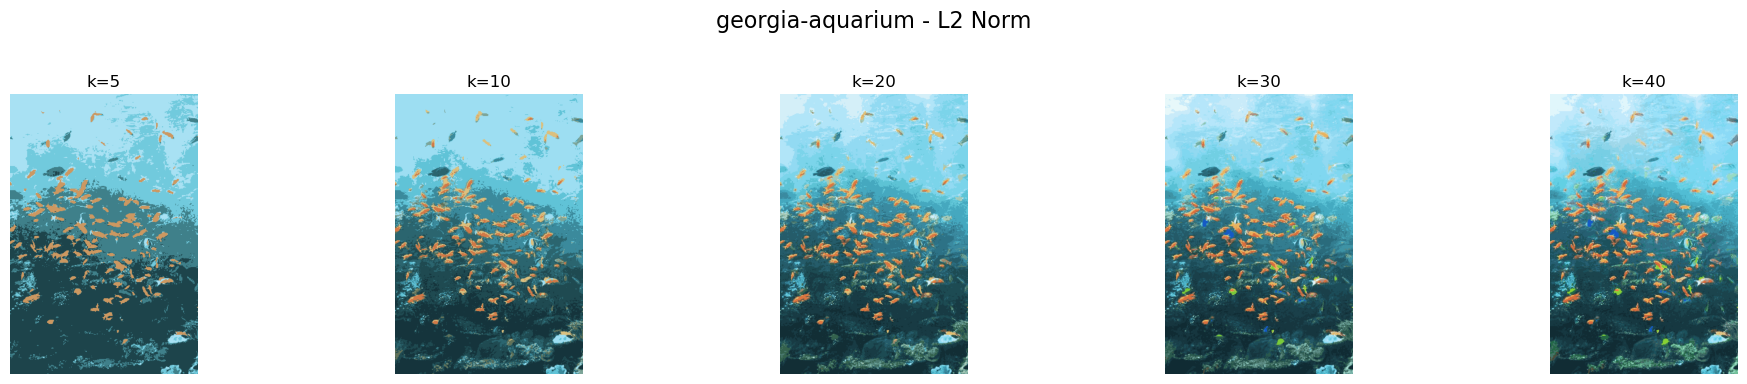


  football - L2 Norm:


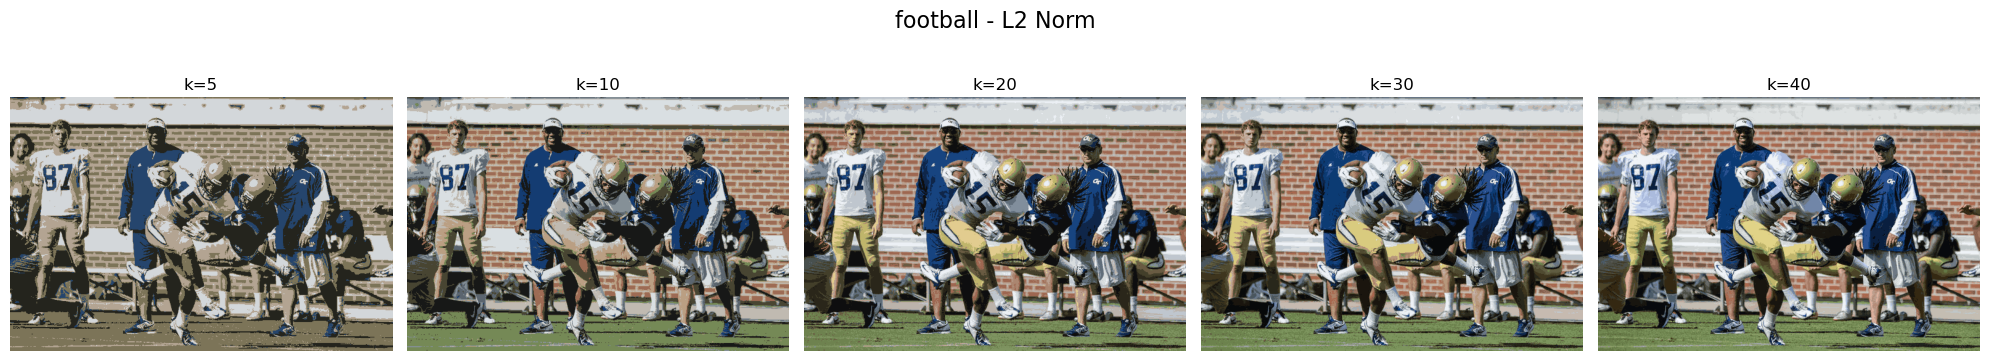


  flower - L2 Norm:


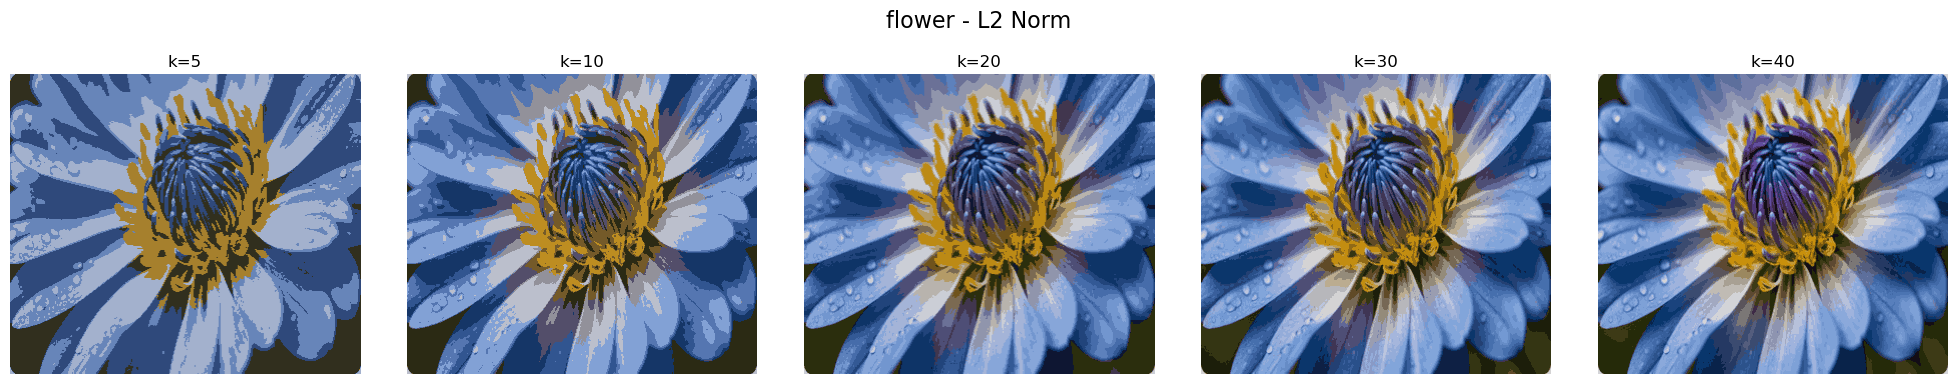


Images with L1 Norm:

  georgia-aquarium - L1 Norm:


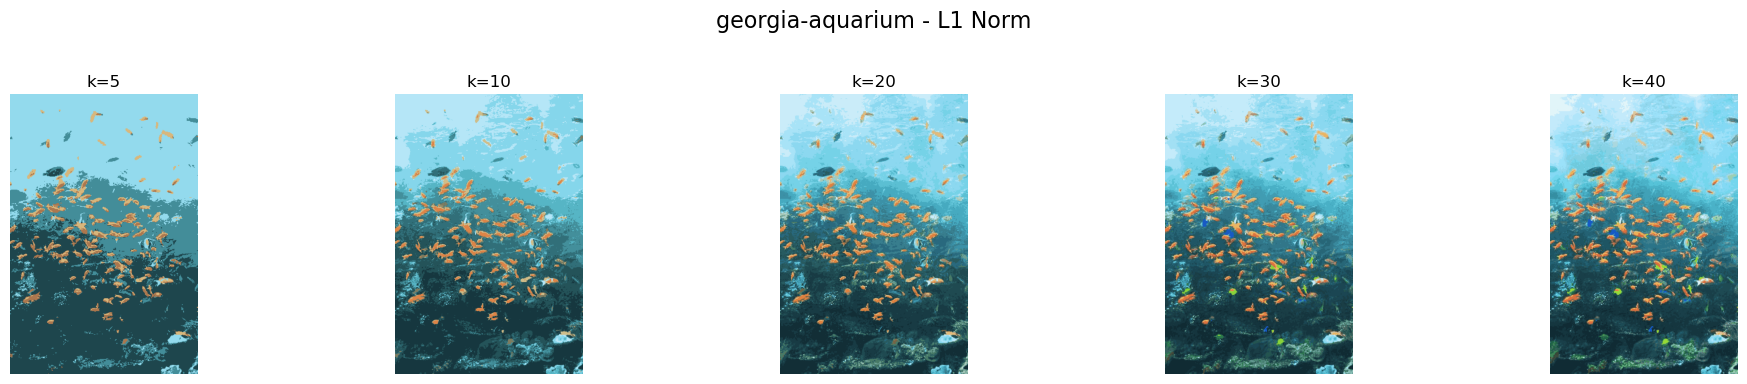


  football - L1 Norm:


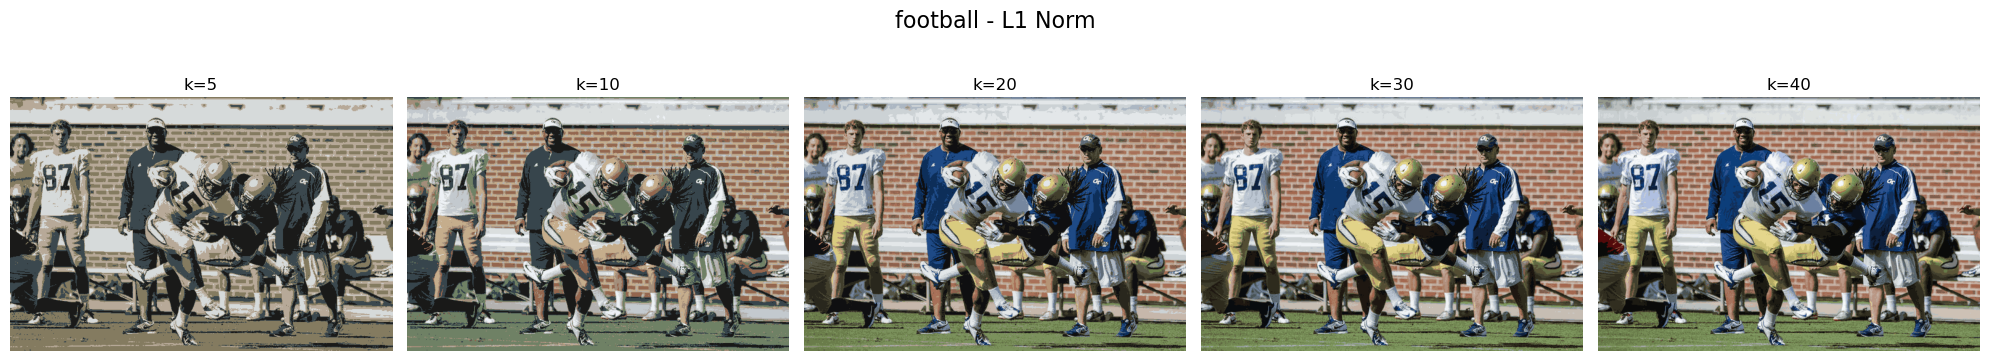


  flower - L1 Norm:


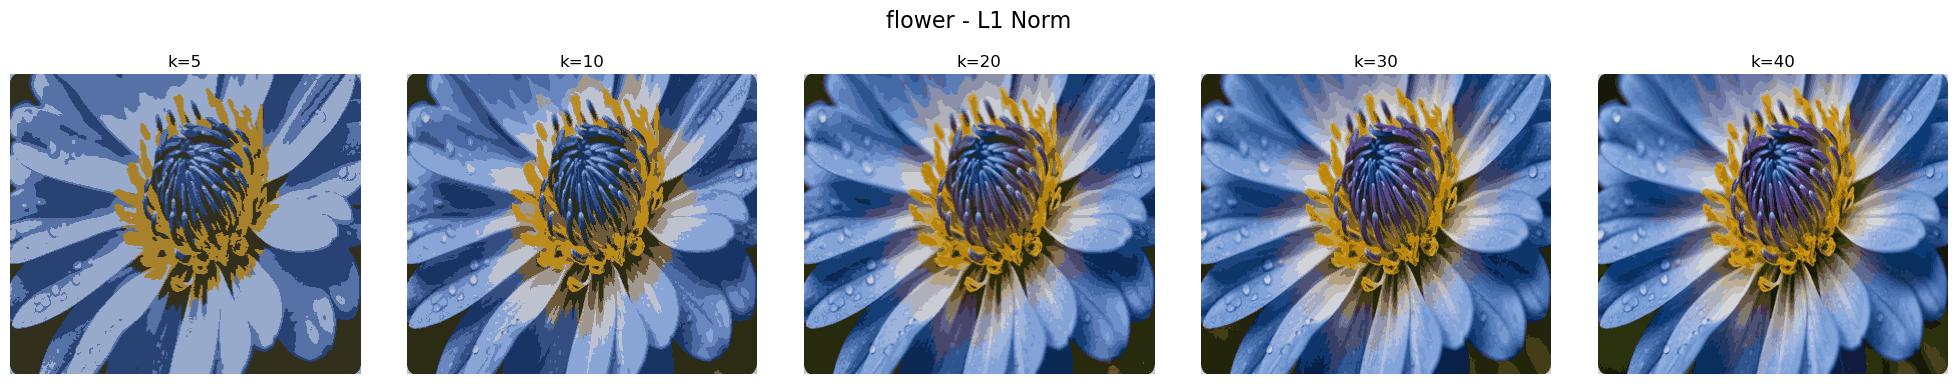


--- End of Image Visualization ---


In [5]:
# Cell 5: Optional - Visualize Reconstructed Images

print("\n--- Displaying Reconstructed Images ---")

for dist_type in norm_distances.keys():
    print(f"\nImages with {dist_type.upper()} Norm:")
    for image_name in image_paths.keys():
        print(f"\n  {image_name} - {dist_type.upper()} Norm:")
        fig, axes = plt.subplots(1, len(k_values), figsize=(20, 4))
        fig.suptitle(f"{image_name} - {dist_type.upper()} Norm", fontsize=16)

        for i, k in enumerate(k_values):
            img_path = all_results[dist_type][image_name]['reconstructed_image_paths'][k]
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(f"k={k}")
            axes[i].axis('off')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
        plt.show()

print("\n--- End of Image Visualization ---")


--- Plotting Elbow Graphs ---

Elbow Graphs for L2 norm:


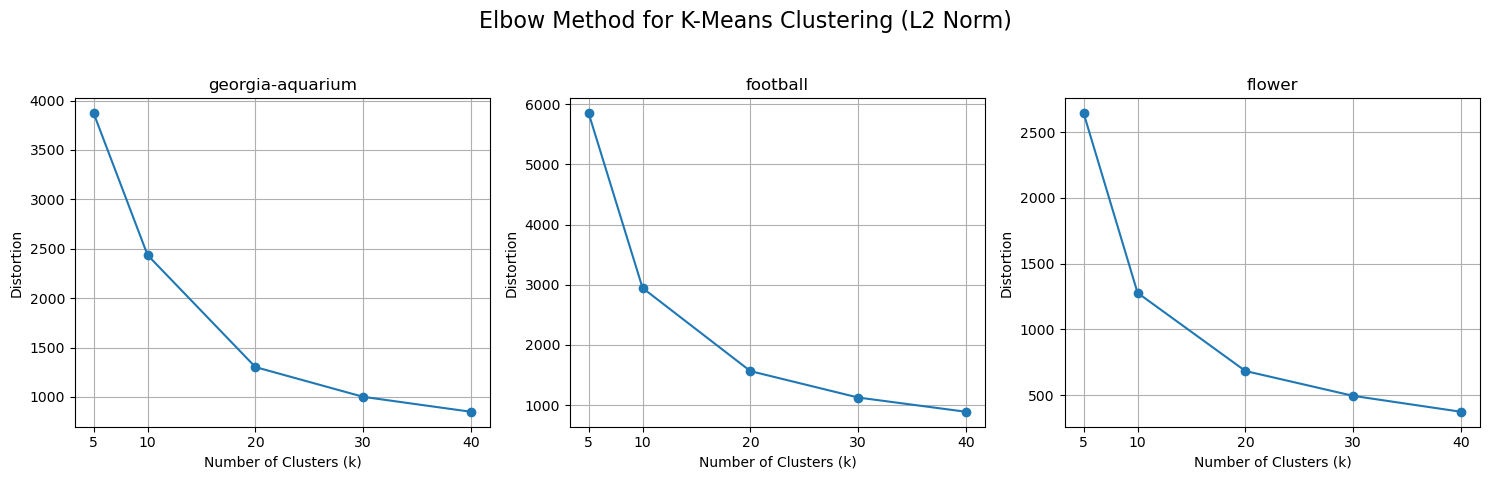


Elbow Graphs for L1 norm:


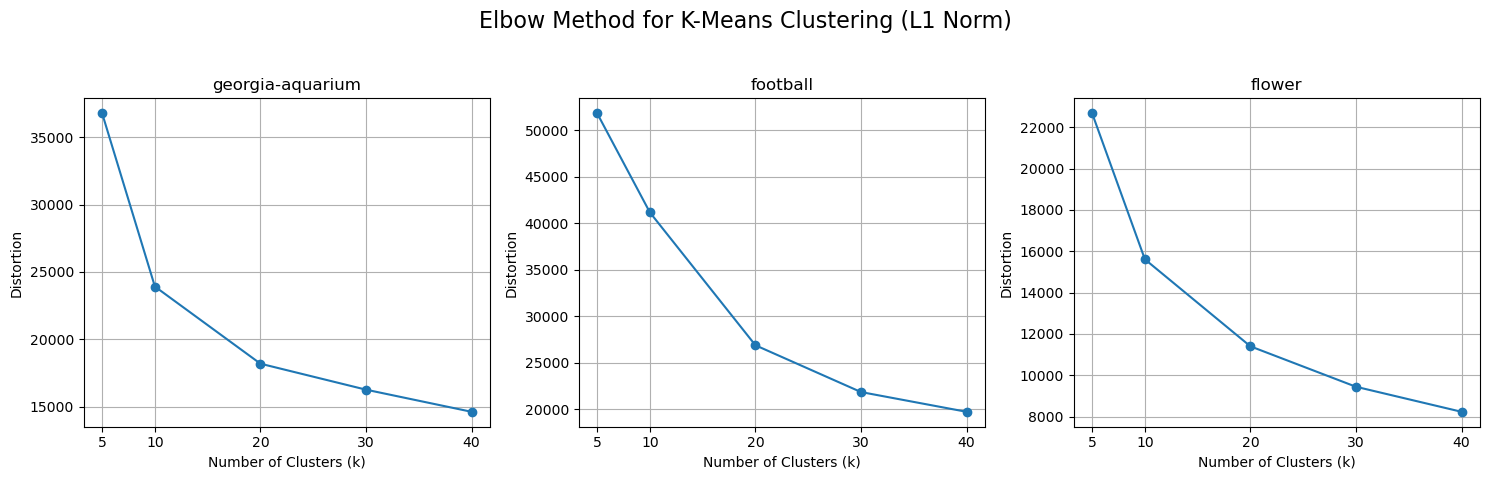


--- Elbow Graph Plotting Complete ---
Examine these plots to identify the 'elbow' point for each image and determine the optimal k.


In [6]:
# Cell 6: Plotting Elbow Graphs

print("\n--- Plotting Elbow Graphs ---")

# Ensure k_values are defined for plotting
# If you changed them in Cell 2, make sure this reflects it.
k_values = [5, 10, 20, 30, 40]

for dist_type, img_results in all_results.items():
    print(f"\nElbow Graphs for {dist_type.upper()} norm:")
    
    plt.figure(figsize=(15, 5))
    plt.suptitle(f"Elbow Method for K-Means Clustering ({dist_type.upper()} Norm)", fontsize=16)

    for i, (image_name, data) in enumerate(img_results.items()):
        plt.subplot(1, len(img_results), i + 1)
        plt.plot(k_values, data['distortions'], marker='o', linestyle='-')
        plt.title(f"{image_name}")
        plt.xlabel("Number of Clusters (k)")
        plt.ylabel("Distortion")
        plt.grid(True)
        plt.xticks(k_values) # Ensure only tested k values are shown on x-axis

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

print("\n--- Elbow Graph Plotting Complete ---")
print("Examine these plots to identify the 'elbow' point for each image and determine the optimal k.")